In [ ]:
!python --version

Python 3.12.13


In [ ]:
!apt-get update
!apt-get install -y openjdk-11-jdk

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:9 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,545 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:13 https://ppa.launchpadcontent.net/graphics-driver

In [ ]:
!wget https://github.com/vncorenlp/VnCoreNLP/archive/refs/heads/master.zip
!unzip master.zip

--2026-04-22 03:13:25--  https://github.com/vncorenlp/VnCoreNLP/archive/refs/heads/master.zip
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/vncorenlp/VnCoreNLP/zip/refs/heads/master [following]
--2026-04-22 03:13:25--  https://codeload.github.com/vncorenlp/VnCoreNLP/zip/refs/heads/master
Resolving codeload.github.com (codeload.github.com)... 140.82.116.9
Connecting to codeload.github.com (codeload.github.com)|140.82.116.9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘master.zip’

master.zip              [             <=>    ] 160.84M  26.8MB/s    in 6.8s    

2026-04-22 03:13:32 (23.6 MB/s) - ‘master.zip’ saved [168648997]

Archive:  master.zip
62bbc58fe5d113c898eae112656be97dcf50b3a0
   creating: VnCoreNLP-master/
  inflating: VnCoreNLP-master/LICENSE.md  


In [ ]:
!pip install datasets
!pip install vncorenlp
!pip install wandb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 40.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for vncorenlp: filename=vncorenlp-1.0.3-py3-none-any.whl size=2645933 sha256=4763ee29a11f5557f39aed4eb65cb98906aca5b85989e81e6c453cd944c54327
  Stored in directory: /root/.cache/pip/wheels/6f/19/20/ec7083125fd06db1a19d0d3ca18806ecf4e8ed1464713b4efa
Successfully built vncorenlp


In [ ]:
!pip install huggingface_hub
from huggingface_hub import notebook_login
import wandb

notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
wandb.login()

# \

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: huyhoang20451 (huyhoang20451-fpt-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
# Login lại nếu restart
# !wandb login --relogin

In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
import seaborn as sns
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import torch.nn.functional as F

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModel,
    TrainingArguments,
    EarlyStoppingCallback,
    Trainer
)
from sklearn.metrics import accuracy_score, f1_score


In [ ]:
from datasets import load_dataset

DATASET_NAME = ""

dataset = load_dataset(DATASET_NAME)["train"]

# Giữ lại user_query và Emotion cho PhoBERT
dataset = dataset.select_columns(["user_query", "Emotion"])

print(dataset)

README.md:   0%|          | 0.00/354 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.71M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10909 [00:00<?, ? examples/s]

Dataset({
    features: ['user_query', 'Emotion'],
    num_rows: 10909
})


In [ ]:
import re
import pandas as pd

clean_teencode_dict = {
    # phổ biến - cần normalize
    "khôg": "không", "hôg": "không", "hok": "không", "ko": "không", "k": "không", "kh": "không", "kô": "không",
    "bik": "biết", "biet": "biết", "biêt": "biết",
    "mih": "mình", "mik": "mình", "mk": "mình", "mjh": "mình",
    "mn": "mọi người", "mng": "mọi người",
    "ng": "người", "ngta": "người ta", "nta": "người ta",
    "bn": "bạn", "bme": "bố mẹ",
    "cx": "cũng", "cũg": "cũng", "kũg": "cũng",
    "vs": "với",
    "đc": "được", "dc": "được", "đươc": "được", "đuợc": "được",
    "z": "vậy", "zậy": "vậy", "zạ": "vậy",
    "ntn": "như thế nào", "nthe": "như thế", "nthế": "như thế", "nvay": "như vậy", "nvậy": "như vậy",
    "trc": "trước", "htrc": "hôm trước",
    "hnay": "hôm nay", "hqua": "hôm qua",
    "ms": "mới",
    "r": "rồi", "oy": "rồi", "zồi": "rồi", "zùi": "rồi",
    "jo": "giờ",
    "ns": "nói",
    "nch": "nói chuyện",
    "lm": "làm",
    "lgi": "làm gì",
    "ntnao": "như thế nào",
    "thjk": "thích", "thik": "thích", "thíc": "thích",
    "iu": "yêu",
    "ny": "người yêu", "nyc": "người yêu cũ",
    "ib": "inbox",
    "kb": "kết bạn",
    "acc": "tài khoản",
    "cviec": "công việc",
    "cty": "công ty",
    "tgian": "thời gian", "thgian": "thời gian",
    "đt": "điện thoại", "đthoai": "điện thoại", "đthoại": "điện thoại",
    "stk": "số tài khoản",
    "sđt": "số điện thoại",
    "gđ": "gia đình", "gđình": "gia đình",
    "bh": "bao giờ", "baoh": "bao giờ",
    "bnhiu": "bao nhiêu", "bnhiêu": "bao nhiêu",
    "qtam": "quan tâm", "qtâm": "quan tâm", "wtâm": "quan tâm",
    "ktra": "kiểm tra",
    "đki": "đăng ký", "đky": "đăng ký", "dky": "đăng ký",
    "vde": "vấn đề", "vđê": "vấn đề",
    "lquan": "liên quan", "klq": "không liên quan",
    "llac": "liên lạc",
    "ctrinh": "chương trình", "ctrình": "chương trình", "ctr": "chương trình",
    "svtn": "sinh viên tình nguyện",
    "sviên": "sinh viên",
    "đhọc": "đại học",
    "thpt": "trung học phổ thông",
    "nvqs": "nghĩa vụ quân sự"
}

# Dấu hiệu Teencode (Ký tự lạ hoặc lặp âm)
teencode_re = r'([a-z])\1{2,}|(vcl|vl|đcm|vãi|uk|uh)'

def classify_query_batch(examples):
    results = []

    for text in examples["user_query"]:
        text_lower = str(text).lower()

        if re.search(teencode_re, text_lower):
            results.append("Teencode")
        elif any(word in text_lower.split() for word in clean_teencode_dict.keys()):
            results.append("Abbreviation")
        else:
            results.append("Standard")

    examples["classify_query"] = results
    return examples

dataset = dataset.map(classify_query_batch, batched=True)

from collections import Counter

counts = Counter(dataset["classify_query"])
print(counts)

Map:   0%|          | 0/10909 [00:00<?, ? examples/s]

Counter({'Standard': 10362, 'Abbreviation': 519, 'Teencode': 28})


In [ ]:
def clean_vntk(text):
    text = str(text).lower()

    # 1. normalize teencode
    words = text.split()
    words = [clean_teencode_dict[w] if w in clean_teencode_dict else w for w in words]
    text = " ".join(words)

    # 2. remove special char (giữ ! ?)
    text = re.sub(r'[^a-zA-ZÀ-ỹ0-9!? ]', ' ', text)

    # 3. normalize kéo dài
    text = re.sub(r'([a-z])\1{2,}', r'\1', text)

    return text

def clean_batch(examples):
    examples["user_query"] = [
        clean_vntk(text) for text in examples["user_query"]
    ]
    return examples

# Thực thi làm sạch
dataset = dataset.map(clean_batch, batched=True)

Map:   0%|          | 0/10909 [00:00<?, ? examples/s]

In [ ]:
# Gom các nhãn có cảm xúc gần giống nhau
label_groups = {
    # sadness cluster
    'Buồn bã': 'Sadness',
    'Cô đơn': 'Sadness',
    'Hối tiếc': 'Sadness',
    # anxiety / fear cluster
    'Lo âu': 'Anxiety_Fear',
    'Sợ hãi': 'Anxiety_Fear',
    # anger cluster
    'Tức giận': 'Anger',
    'Chán ghét': 'Anger',
    # positive
    'Vui vẻ': 'Positive',
    'Lạc quan': 'Positive',
    'Ngạc nhiên': 'Positive',
    # neutral
    'Trung lập': 'Neutral',
    'Other': 'Neutral',
    # highly neg
    'Highly negative': 'Highly_Negative'
}

def map_coarse(example):
    example["Emotion_coarse"] = label_groups[example["Emotion"]]
    return example

dataset = dataset.map(map_coarse)

Map:   0%|          | 0/10909 [00:00<?, ? examples/s]

In [ ]:
# Tạo label2id và id2label cho phobert

from datasets import ClassLabel
# Encode fine
fine_labels = sorted(dataset.unique("Emotion"))
fine_class = ClassLabel(names=fine_labels)

dataset = dataset.cast_column("Emotion", fine_class)

# Encode coarse
coarse_labels = sorted(dataset.unique("Emotion_coarse"))
coarse_class = ClassLabel(names=coarse_labels)

dataset = dataset.cast_column("Emotion_coarse", coarse_class)

# Lấy mapping cho model
label2id_fine = dataset.features["Emotion"]._str2int
id2label_fine = dataset.features["Emotion"]._int2str

label2id_coarse = dataset.features["Emotion_coarse"]._str2int
id2label_coarse = dataset.features["Emotion_coarse"]._int2str

Casting the dataset:   0%|          | 0/10909 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/10909 [00:00<?, ? examples/s]

In [ ]:
# Word segmentation sử dụng VnCoreNLP
from vncorenlp import VnCoreNLP

# Đường dẫn tới thư mục chứa file jar
rdrsegmenter = VnCoreNLP(
    "VnCoreNLP-master/VnCoreNLP-1.1.1.jar",
    annotators="wseg",
    max_heap_size='-Xmx2g'
)

def word_segment(text):
    sentences = rdrsegmenter.tokenize(text)
    return " ".join([" ".join(sent) for sent in sentences])

def segment_function(examples):
    examples["user_query"] = [word_segment(t) for t in examples["user_query"]]
    return examples

# Áp dụng vào dataset
dataset = dataset.map(segment_function, batched=True)

Map:   0%|          | 0/10909 [00:00<?, ? examples/s]

In [ ]:
# Train/Val/Test Split: 0.7-0.15-0.15
# Train
dataset_split = dataset.train_test_split(
    test_size=0.3,
    stratify_by_column="Emotion_coarse",
    seed=42
)

train_dataset = dataset_split["train"]
temp_dataset = dataset_split["test"]

# Test/Val
temp_split = temp_dataset.train_test_split(
    test_size=0.5,
    stratify_by_column="Emotion_coarse",
    seed=42
)

val_dataset = temp_split["train"]
test_dataset = temp_split["test"]

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 7636
Validation: 1636
Test: 1637


In [ ]:
from transformers import DataCollatorWithPadding

# Tokenization sử dụng PhoBERT
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base", use_fast=False)

def tokenize_function(examples):
    return tokenizer(examples["user_query"], truncation=True, max_length=256)


# Áp dụng vào dataset
train_tokenized = train_dataset.map(tokenize_function, batched=True)\
                              .rename_column("Emotion", "labels_fine")\
                              .rename_column("Emotion_coarse", "labels_coarse")\
                              .remove_columns(["user_query"])

val_tokenized = val_dataset.map(tokenize_function, batched=True)\
                          .rename_column("Emotion", "labels_fine")\
                          .rename_column("Emotion_coarse", "labels_coarse")\
                          .remove_columns(["user_query"])

test_tokenized = test_dataset.map(tokenize_function, batched=True)\
                           .rename_column("Emotion", "labels_fine")\
                           .rename_column("Emotion_coarse", "labels_coarse")\
                           .remove_columns(["user_query"])

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/7636 [00:00<?, ? examples/s]

Map:   0%|          | 0/1636 [00:00<?, ? examples/s]

Map:   0%|          | 0/1637 [00:00<?, ? examples/s]

In [ ]:
# 5: Format for PyTorch
train_tokenized.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels_fine", "labels_coarse"]
)

val_tokenized.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels_fine", "labels_coarse"]
)

test_tokenized.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels_fine", "labels_coarse"]
)

In [ ]:
class PhoBERTMultiHead(nn.Module):
    def __init__(self, model_name, num_fine, num_coarse):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size

        # Thêm tầng đệm
        self.dense = nn.Linear(hidden_size, hidden_size)
        self.activation = nn.Tanh() # Giúp mô hình học các biểu diễn phi tuyến tính
        self.dropout = nn.Dropout(0.1)

        # Classification heads
        self.classifier_fine = nn.Linear(hidden_size, num_fine)
        self.classifier_coarse = nn.Linear(hidden_size, num_coarse)

        # # Biến học cho Dynamic Loss Weighting
        # self.log_vars = nn.Parameter(torch.zeros(2))

    def forward(self, input_ids, attention_mask, labels_fine=None, labels_coarse=None):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)

        # Tối ưu trích xuất đặc trưng: Dùng pooler_output nếu có, nếu không thì dùng CLS token
        if hasattr(outputs, 'pooler_output') and outputs.pooler_output is not None:
            pooled = outputs.pooler_output
        else:
            pooled = outputs.last_hidden_state[:, 0]

        # Tầng đệm
        pooled = self.dropout(pooled)
        pooled = self.dense(pooled)
        pooled = self.activation(pooled)
        pooled = self.dropout(pooled)

        # Tính logits
        logits_fine = self.classifier_fine(pooled)
        logits_coarse = self.classifier_coarse(pooled)

        loss = None
        if labels_fine is not None and labels_coarse is not None:

            # Label smoothing (do label gộp bị mất cân bằng)
            loss_fct = nn.CrossEntropyLoss(label_smoothing=0.1)

            loss_fine = loss_fct(logits_fine, labels_fine)
            loss_coarse = loss_fct(logits_coarse, labels_coarse)

            # # Dynamic Uncertainty Weighting (bị catastrophic forgetting)
            # # Công thức: Loss = exp(-log_var) * Task_Loss + log_var
            # # Mô hình sẽ tự động tìm tỷ lệ hoàn hảo giữa Fine và Coarse thay vì fix cứng
            # loss_0 = torch.exp(-self.log_vars[0]) * loss_fine + self.log_vars[0]
            # loss_1 = torch.exp(-self.log_vars[1]) * loss_coarse + self.log_vars[1]

            # loss = loss_0 + loss_1

            loss = 0.7 * loss_fine + 0.3 * loss_coarse

        return {
            "loss": loss,
            "logits": (logits_fine, logits_coarse)
        }

In [ ]:
from transformers import TrainerCallback

class WandbCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            wandb.log(logs)

class MultiTaskTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # 2 input
        labels_fine = inputs.get("labels_fine")
        labels_coarse = inputs.get("labels_coarse")

        outputs = model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            labels_fine=labels_fine,
            labels_coarse=labels_coarse
        )

        loss = outputs["loss"]

        return (loss, outputs) if return_outputs else loss

# Data collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    # predictions là tuple nếu bạn return nhiều logits
    logits_fine, logits_coarse = predictions
    labels_fine, labels_coarse = labels

    # Lấy class dự đoán
    preds_fine = logits_fine.argmax(axis=-1)
    preds_coarse = logits_coarse.argmax(axis=-1)

    # ===== Fine metrics =====
    acc_fine = accuracy_score(labels_fine, preds_fine)
    f1_fine_macro = f1_score(labels_fine, preds_fine, average="macro")
    f1_fine_weighted = f1_score(labels_fine, preds_fine, average="weighted")

    # ===== Coarse metrics =====
    acc_coarse = accuracy_score(labels_coarse, preds_coarse)
    f1_coarse_macro = f1_score(labels_coarse, preds_coarse, average="macro")

    return {
        "accuracy_fine": acc_fine,
        "f1_fine_macro": f1_fine_macro,
        "f1_fine_weighted": f1_fine_weighted,

        "accuracy_coarse": acc_coarse,
        "f1_coarse_macro": f1_coarse_macro,
    }

In [ ]:
# init wandb
wandb.init(
    project="",
    name=""
)

model = PhoBERTMultiHead("vinai/phobert-large", len(label2id_fine), len(label2id_coarse))

training_args = TrainingArguments(
    output_dir="./phobert-multitask",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=8,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="eval_accuracy_fine",
    greater_is_better=True,

    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    weight_decay=0.02,

    report_to="wandb",
)

trainer = MultiTaskTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[WandbCallback(), EarlyStoppingCallback(early_stopping_patience=1)]
)

trainer.train()

trainer.evaluate(test_tokenized)

wandb.finish()

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.48G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.48G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-large
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy Fine,F1 Fine Macro,F1 Fine Weighted,Accuracy Coarse,F1 Coarse Macro
1,2.073161,1.378883,0.614914,0.581198,0.575753,0.738386,0.639169
2,1.218834,1.087184,0.735941,0.745676,0.738577,0.808068,0.795305
3,0.974144,1.072614,0.747555,0.750717,0.743572,0.822127,0.802151
4,0.831973,1.064429,0.748166,0.756981,0.749941,0.827628,0.815009
5,0.730475,1.092556,0.753056,0.762004,0.754805,0.822127,0.807262
6,0.658474,1.107625,0.763447,0.771504,0.764578,0.825183,0.810100
7,0.621715,1.124855,0.758557,0.767244,0.759909,0.821516,0.806869


epoch,▁▁▂▂▃▃▅▅▆▆▇▇████
eval/accuracy_coarse,▁▆█████▇
eval/accuracy_fine,▁▇▇▇████
eval/f1_coarse_macro,▁▇▇█████
eval/f1_fine_macro,▁▇▇▇████
eval/f1_fine_weighted,▁▇▇▇████
eval/loss,█▂▁▁▂▂▂▃
eval/runtime,▁▃▅▁▂▁▂█
eval/samples_per_second,█▆▃█▇█▇▁
eval/steps_per_second,█▆▃█▇█▇▁
+22,...


In [ ]:
# init wandb
wandb.init(
    project="PhoBERT_ex",
    name="MultiheadModel_report_12"
)

from sklearn.metrics import classification_report
import numpy as np

# ===== Predict =====
predictions = trainer.predict(test_tokenized)

logits_fine, logits_coarse = predictions.predictions

preds_fine = np.argmax(logits_fine, axis=-1)
preds_coarse = np.argmax(logits_coarse, axis=-1)

labels_fine = predictions.label_ids[0]
labels_coarse = predictions.label_ids[1]

# ===== Label names (QUAN TRỌNG) =====
target_names_fine = [id2label_fine[i] for i in range(len(id2label_fine))]
target_names_coarse = [id2label_coarse[i] for i in range(len(id2label_coarse))]

labels_fine_ids = list(range(len(target_names_fine)))
labels_coarse_ids = list(range(len(target_names_coarse)))

# ===== Report =====
print("========== FINE CLASSIFICATION ==========")
print(classification_report(
    labels_fine,
    preds_fine,
    labels=labels_fine_ids,
    target_names=target_names_fine,
    digits=4,
    zero_division=0
))

print("\n========== COARSE CLASSIFICATION ==========")
print(classification_report(
    labels_coarse,
    preds_coarse,
    labels=labels_coarse_ids,
    target_names=target_names_coarse,
    digits=4,
    zero_division=0
))

test/accuracy_coarse,▁
test/accuracy_fine,▁
test/f1_coarse_macro,▁
test/f1_fine_macro,▁
test/f1_fine_weighted,▁
test/loss,▁
test/runtime,▁
test/samples_per_second,▁
test/steps_per_second,▁
test/accuracy_coarse,0.81491
test/accuracy_fine,0.75321


========== FINE CLASSIFICATION ==========
                 precision    recall  f1-score   support

        Buồn bã     0.6294    0.5912    0.6097       181
      Chán ghét     0.6929    0.7788    0.7333       113
         Cô đơn     0.7302    0.7731    0.7510       119
Highly negative     0.7207    0.6897    0.7048       116
       Hối tiếc     0.8242    0.7282    0.7732       103
          Lo âu     0.5893    0.6387    0.6130       155
       Lạc quan     0.7368    0.7417    0.7393       151
     Ngạc nhiên     0.9016    0.9244    0.9129       119
          Other     0.9016    0.9244    0.9129       119
         Sợ hãi     0.8396    0.7876    0.8128       113
      Trung lập     0.5897    0.6000    0.5948       115
       Tức giận     0.9402    0.9091    0.9244       121
         Vui vẻ     0.8519    0.8214    0.8364       112

       accuracy                         0.7532      1637
      macro avg     0.7652    0.7622    0.7630      1637
   weighted avg     0.7554    0.7532    0.75

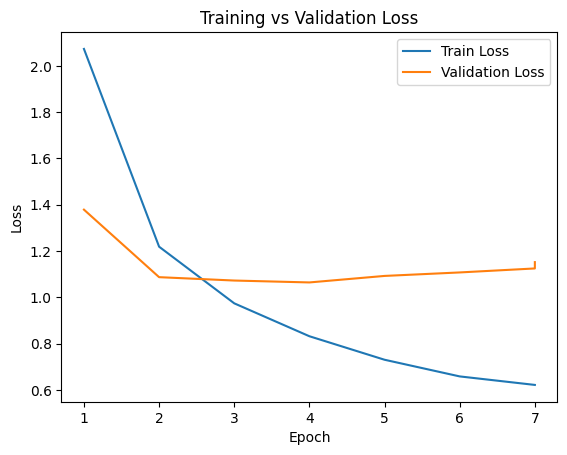

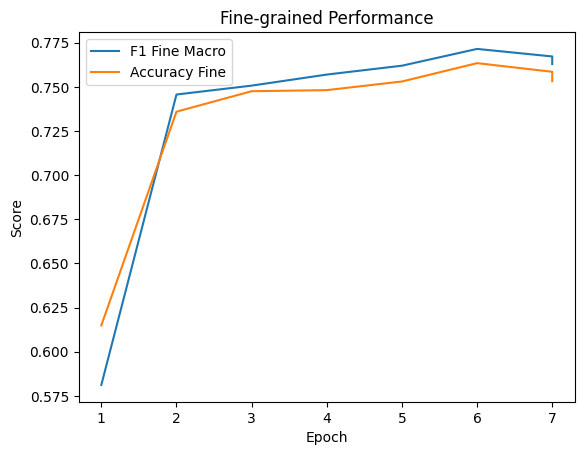

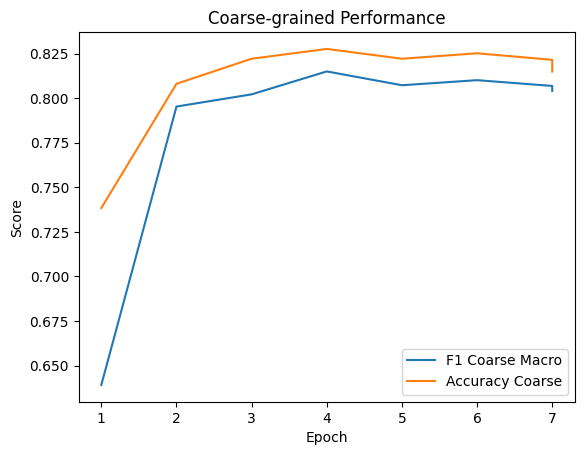

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(trainer.state.log_history)

train_df = df[df["loss"].notna()]
eval_df = df[df["eval_loss"].notna()]

plt.figure()
plt.plot(train_df["epoch"], train_df["loss"], label="Train Loss")
plt.plot(eval_df["epoch"], eval_df["eval_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


# ===== Fine metrics =====
plt.figure()
plt.plot(eval_df["epoch"], eval_df["eval_f1_fine_macro"], label="F1 Fine Macro")
plt.plot(eval_df["epoch"], eval_df["eval_accuracy_fine"], label="Accuracy Fine")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Fine-grained Performance")
plt.legend()
plt.show()


# ===== Coarse metrics =====
plt.figure()
plt.plot(eval_df["epoch"], eval_df["eval_f1_coarse_macro"], label="F1 Coarse Macro")
plt.plot(eval_df["epoch"], eval_df["eval_accuracy_coarse"], label="Accuracy Coarse")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Coarse-grained Performance")
plt.legend()
plt.show()

In [ ]:
def log_confusion_matrix(
    y_true,
    y_pred,
    class_names,
    title="Confusion Matrix",
    normalize=True,
    log_wandb=True
):
    # ===== 1. Compute CM =====
    cm = confusion_matrix(
        y_true,
        y_pred,
        normalize="true" if normalize else None
    )

    # ===== 2. Plot =====
    plt.figure(figsize=(12, 10))

    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f" if normalize else "d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={'label': 'Proportion' if normalize else 'Count'}
    )

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    plt.tight_layout()

    # ===== 3. Log to wandb =====
    if log_wandb:
        wandb.log({title: wandb.Image(plt)})

    plt.show()
    plt.close()

test/accuracy_coarse,▁
test/accuracy_fine,▁
test/f1_coarse_macro,▁
test/f1_fine_macro,▁
test/f1_fine_weighted,▁
test/loss,▁
test/runtime,▁
test/samples_per_second,▁
test/steps_per_second,▁
test/accuracy_coarse,0.81491
test/accuracy_fine,0.75321


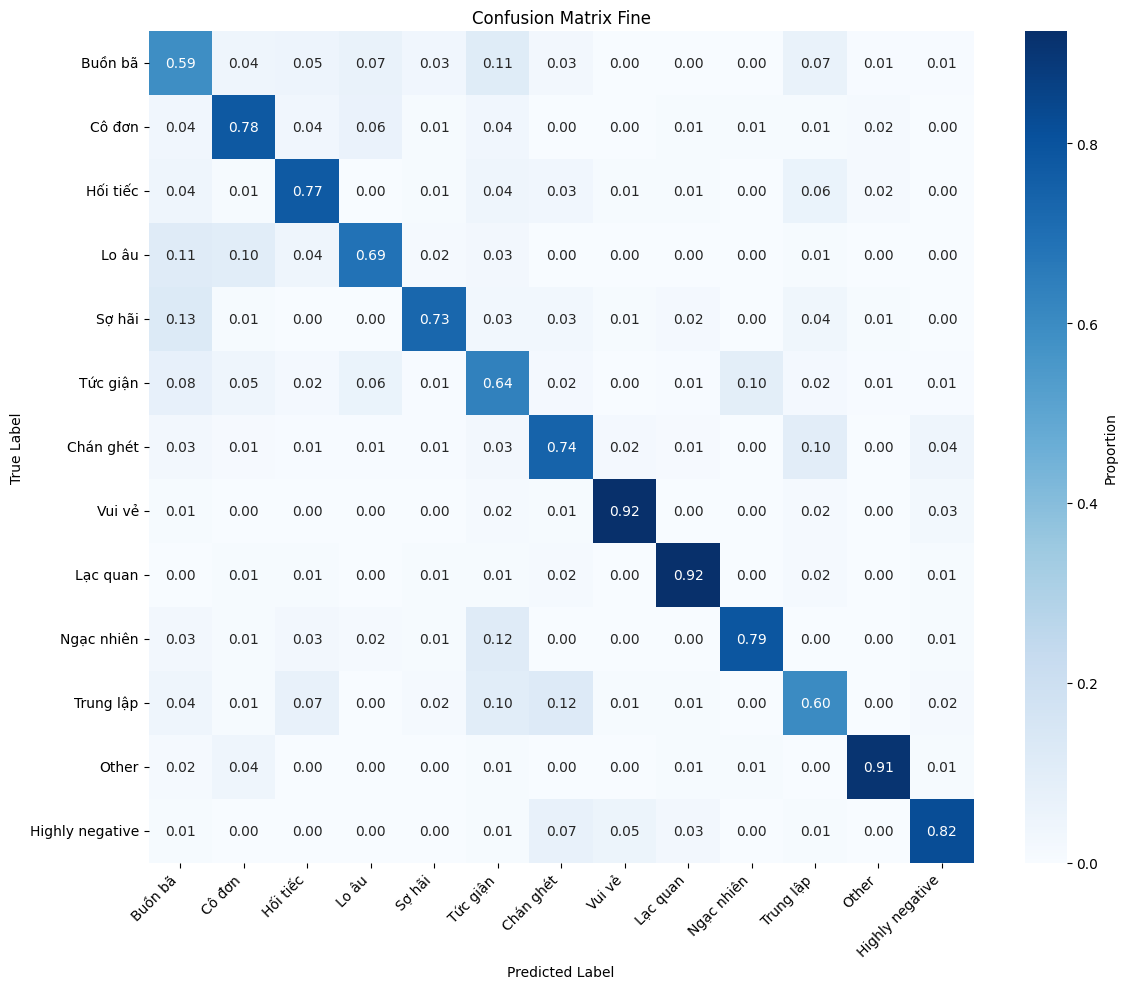

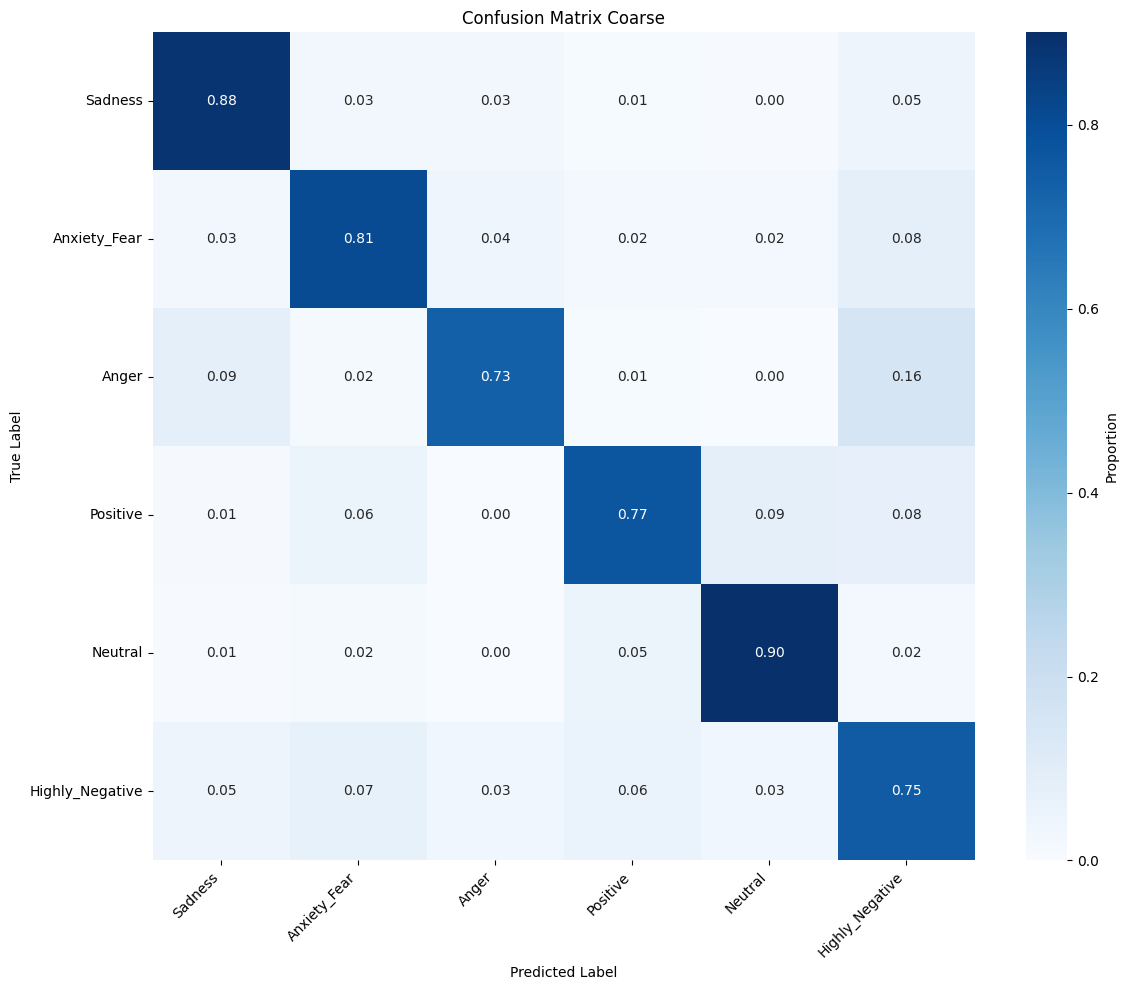

In [ ]:
# init wandb
wandb.init(
    project="PhoBERT_ex",
    name="MultiheadModel_report_12"
)

def get_predictions(trainer, dataset):
    # Lấy output từ trainer
    predictions, _, _ = trainer.predict(dataset)

    # Custom model trả về tuple (logits_fine, logits_coarse)
    logits_fine, logits_coarse = predictions

    # Lấy nhãn dự đoán (argmax)
    preds_fine = np.argmax(logits_fine, axis=1)
    preds_coarse = np.argmax(logits_coarse, axis=1)

    # Lấy nhãn thực tế từ dataset
    labels_fine = dataset["labels_fine"]
    labels_coarse = dataset["labels_coarse"]

    return preds_fine, preds_coarse, labels_fine, labels_coarse

preds_fine, preds_coarse, labels_fine, labels_coarse = get_predictions(trainer, test_tokenized)

fine_label_names = [
    "Buồn bã",
    "Cô đơn",
    "Hối tiếc",
    "Lo âu",
    "Sợ hãi",
    "Tức giận",
    "Chán ghét",
    "Vui vẻ",
    "Lạc quan",
    "Ngạc nhiên",
    "Trung lập",
    "Other",
    "Highly negative"
]

coarse_label_names = [
    "Sadness",
    "Anxiety_Fear",
    "Anger",
    "Positive",
    "Neutral",
    "Highly_Negative"
]


log_confusion_matrix(labels_fine, preds_fine, fine_label_names, "Confusion Matrix Fine")
log_confusion_matrix(labels_coarse, preds_coarse, coarse_label_names, "Confusion Matrix Coarse")

In [ ]:
torch.save(model.state_dict(), "pytorch_model.bin")

from huggingface_hub import create_repo, upload_file

repo_id = "usernone1234/phobert-multihead-weights"

create_repo(repo_id, repo_type="model", exist_ok=True)

upload_file(
    path_or_fileobj="pytorch_model.bin",
    path_in_repo="pytorch_model.bin",
    repo_id=repo_id
)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  pytorch_model.bin           :   0%|          |  559kB / 1.48GB            

CommitInfo(commit_url='https://huggingface.co/usernone1234/phobert-multihead-weights/commit/6d8907f80065f7a45a60b10d03e17f52610ac9da', commit_message='Upload pytorch_model.bin with huggingface_hub', commit_description='', oid='6d8907f80065f7a45a60b10d03e17f52610ac9da', pr_url=None, repo_url=RepoUrl('https://huggingface.co/usernone1234/phobert-multihead-weights', endpoint='https://huggingface.co', repo_type='model', repo_id='usernone1234/phobert-multihead-weights'), pr_revision=None, pr_num=None)